In [56]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib  # To save your model for later use

# Define path to dataset relative to 'realisation/test.ipynb'
# We go one level up ("..") to reach 'project', then into 'DATASET'
DATASET_PATH = os.path.join('..', 'DATASET')

print(f"Looking for data in: {os.path.abspath(DATASET_PATH)}")

Looking for data in: c:\Users\essal\Videos\Master S3\Automatic Speech Recognition\porject\DATASET


In [57]:
def extract_features(file_path):
    try:
        # 1. Load the audio file (resample to 16kHz to be consistent)
        audio, sample_rate = librosa.load(file_path, sr=16000)
        
        # 2. Trim silent edges (optional but recommended)
        audio, _ = librosa.effects.trim(audio)
        
        # 3. Extract MFCCs
        # n_mfcc=13 is the standard number of coefficients used in speech recognition
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
        
        # 4. Average the MFCCs across time
        # We do this because audio files have different lengths. 
        # Averaging gives us a fixed-size vector (13 numbers) for every file.
        mfccs_scaled = np.mean(mfccs.T, axis=0)
        
        return mfccs_scaled
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [58]:
# Lists to hold data
features = []
labels = []

# Verify directory exists
if not os.path.exists(DATASET_PATH):
    print("Error: DATASET path not found. Check your folder structure.")
else:
    print("Processing dataset... This might take a minute.")
    
    # Walk through the directory tree
    # Level 1: Speaker Folders (Abdelaali, Ayat, etc.)
    for speaker in os.listdir(DATASET_PATH):
        speaker_path = os.path.join(DATASET_PATH, speaker)
        
        if os.path.isdir(speaker_path):
            # Level 2: Digit Folders (0, 1, 2... 9)
            for digit in os.listdir(speaker_path):
                digit_path = os.path.join(speaker_path, digit)
                
                if os.path.isdir(digit_path):
                    # Level 3: Audio Files
                    for audio_file in os.listdir(digit_path):
                        if audio_file.endswith('.wav'):
                            file_path = os.path.join(digit_path, audio_file)
                            
                            # Extract features
                            data = extract_features(file_path)
                            
                            if data is not None:
                                features.append(data)
                                labels.append(int(digit)) # The folder name '0' becomes label 0

    print(f"Processed {len(features)} audio files.")

Processing dataset... This might take a minute.
Processed 1594 audio files.


In [68]:
# Convert lists to numpy arrays
X = np.array(features)
y = np.array(labels)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Support Vector Classifier
# kernel='rbf' is usually best for audio as boundaries are rarely linear
clf = SVC(kernel='rbf', C=350, gamma='scale')

# Train the model
print("Training the SVM model...")
clf.fit(X_train, y_train)
print("Training complete.")

# Evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:\n", classification_report(y_test, y_pred))

# Save the model so you don't have to retrain every time
joblib.dump(clf, 'arabic_digit_recognizer.pkl')
print("Model saved as 'arabic_digit_recognizer.pkl'")

Training the SVM model...
Training complete.
Model Accuracy: 87.15%

Detailed Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        28
           1       0.82      0.79      0.81        34
           2       0.89      0.97      0.93        32
           3       0.93      0.76      0.84        37
           4       0.92      0.97      0.95        36
           5       0.69      0.91      0.78        22
           6       0.96      0.90      0.93        29
           7       0.86      0.81      0.83        37
           8       0.79      0.93      0.85        28
           9       0.97      0.83      0.90        36

    accuracy                           0.87       319
   macro avg       0.87      0.88      0.87       319
weighted avg       0.88      0.87      0.87       319

Model saved as 'arabic_digit_recognizer.pkl'


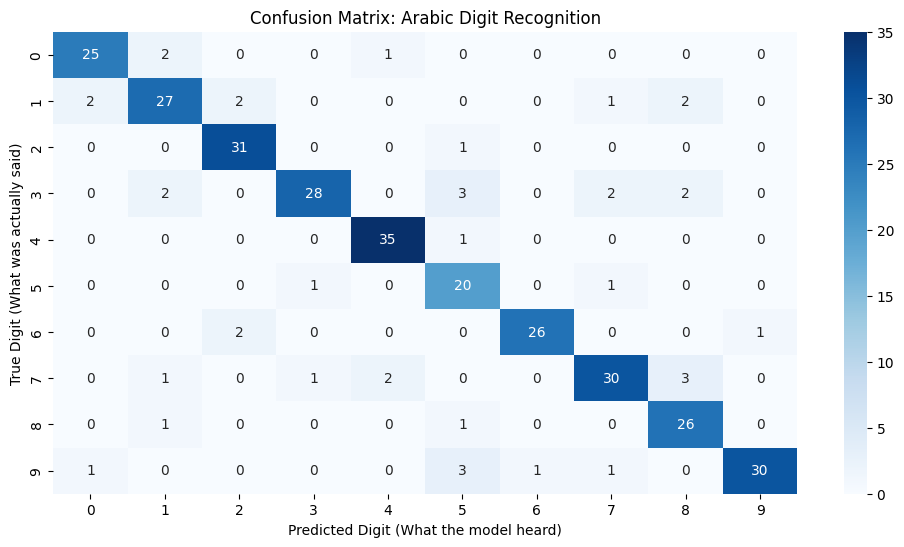

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute the confusion matrix
# y_test are the true labels, y_pred are the labels predicted by your model
cm = confusion_matrix(y_test, y_pred)

# 2. Plotting using Seaborn
plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[str(i) for i in range(10)], 
            yticklabels=[str(i) for i in range(10)])

plt.title('Confusion Matrix: Arabic Digit Recognition')
plt.ylabel('True Digit (What was actually said)')
plt.xlabel('Predicted Digit (What the model heard)')
plt.show()

In [73]:
import IPython.display as ipd

def test_single_file(file_path):
    # 1. Check if file exists
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return

    # 2. Play the audio (so you can hear what the model hears)
    print(f"Testing file: {file_path}")
    ipd.display(ipd.Audio(file_path))

    # 3. Extract features
    # Since your files are already 16kHz/Mono, this loads them quickly
    features = extract_features(file_path)

    if features is not None:
        # 4. Reshape for the classifier (1 sample, 13 features)
        features_vector = features.reshape(1, -1)
        
        # 5. Predict
        prediction = clf.predict(features_vector)
        predicted_digit = prediction[0]
        
        print(f"---------------------------------------")
        print(f"The model thinks this number is:  {predicted_digit}")
        print(f"---------------------------------------")
    else:
        print("Could not process audio file.")

# --- EXAMPLE USAGE ---
# Replace this path with a real file from your DATASET folder
# Example: Testing with a file from 'Abdelaali AIT IDAR' folder, digit '0'
test_file = os.path.join(DATASET_PATH, 'Mohammed ESSALHI', '0', 'R-10.wav') 

test_single_file(test_file)

Testing file: ..\DATASET\Mohammed ESSALHI\0\R-10.wav


---------------------------------------
The model thinks this number is:  0
---------------------------------------
